In [ ]:
# %%
# ---------------- Core Imports ----------------
import os
from dotenv import load_dotenv
load_dotenv()

# ---------------- LangChain & Chroma ----------------
from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_unstructured import UnstructuredLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

from langchain_groq import ChatGroq
from langchain.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain.schema import Document
from langchain_community.utilities import SerpAPIWrapper
from langchain_core.tools import Tool

from langgraph.graph import StateGraph, END
from typing import TypedDict, List, Optional, Literal

# %% [markdown]
# #### File Loaded

# %%
file_path = "test.pdf"

if file_path.endswith(".pdf"):
    loader = PyPDFLoader(file_path)
elif file_path.endswith(".txt"):
    loader = TextLoader(file_path)
else:
    loader = UnstructuredLoader(file_path)

documents = loader.load()
print(f"Loaded {len(documents)} documents")
print(f"First document preview:\n{documents[0].page_content[:500]}")

# %% [markdown]
# #### Text Splitter

# %%
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
docs = text_splitter.split_documents(documents)

print(f"Split into {len(docs)} chunks")
print(f"First chunk preview:\n{docs[0].page_content[:500]}")

# %% [markdown]
# #### Embedded 

# %%
embedding = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"}
)

# %% [markdown]
# #### Vector Store

# %%
vector_store = Chroma.from_documents(
    documents=docs,
    embedding=embedding,
    persist_directory="chroma_db"
)
retriever = vector_store.as_retriever(search_kwargs={"k": 3})
print("Chroma vector store created.")

# %% [markdown]
# #### Model Setup

# %%
load_dotenv()
llm = ChatGroq(
    model_name="llama-3.1-8b-instant",
    api_key=os.getenv("GROQ_API_KEY")
)

# Define output parser
parser = StrOutputParser()

# %% [markdown]
# ### Web Search Tool Setup

# %%
serp_api_key = os.getenv("SERPAPI_API_KEY")
serp = SerpAPIWrapper(serpapi_api_key=serp_api_key)

search_tool = Tool(
    name="Search",
    func=serp.run,
    description="Search web queries when answer not found in documents"
)

# %% [markdown]
# #### Define Graph State

# %%
class GraphState(TypedDict):
    query: str
    docs: Optional[List[Document]]
    answer: Optional[str]
    source: Optional[str]
    use_rag: Optional[bool]

# %% [markdown]
# #### Node Definitions

# %%
def retriever_node(state: GraphState):
    """Retrieve relevant documents from vector store"""
    query = state["query"]
    results = vector_store.similarity_search_with_score(query, k=5)
    
    # Chroma uses distance (lower is better), so we filter by max distance
    # Typical range is 0-2, where 0 is identical
    max_distance = 1.0  # Adjust based on your needs
    filtered_docs = [doc for doc, score in results if score < max_distance]
    
    print(f"📚 Retriever found {len(filtered_docs)} relevant docs (from {len(results)} total)")
    
    # Decide whether to use RAG or web search
    use_rag = len(filtered_docs) > 0
    
    return {
        "docs": filtered_docs,
        "use_rag": use_rag
    }

# %%
def rag_node(state: GraphState):
    """Answer question using retrieved documents"""
    docs = state.get("docs", [])
    query = state["query"]
    
    if not docs:
        return {"answer": "No relevant documents found.", "source": "None"}
    
    context = "\n\n".join([d.page_content for d in docs])
    
    prompt = ChatPromptTemplate.from_template(
        """You are an intelligent assistant. Use the provided context to answer the question.
        If the answer can be found in the context, provide a clear and accurate response.
        If the answer is not present in the context, respond: "Not found in document".

        Context:
        {context}

        Question: {question}

        Answer:"""
    )
    
    chain = prompt | llm | parser
    answer = chain.invoke({"context": context, "question": query})
    
    sources = list(set([d.metadata.get("source", "Unknown") for d in docs]))
    sources_str = ", ".join(sources)
    
    print(f"✅ RAG answered using {len(docs)} documents")
    
    return {
        "answer": answer,
        "source": f"RAG (Documents: {sources_str})"
    }

# %%
def web_search_node(state: GraphState):
    """Search the web when documents don't have the answer"""
    query = state["query"]
    
    print("🌍 Executing web search...")
    result = search_tool.func(query)
    
    return {
        "answer": result,
        "source": "Web Search (SerpAPI)"
    }

# %%
def summarizer_node(state: GraphState):
    """Refine and format the final answer"""
    answer = state.get("answer")
    
    if not answer or answer == "No relevant documents found.":
        return {"answer": answer}
    
    prompt = ChatPromptTemplate.from_template(
        """Refine and format the following answer to be clear, concise, and professional.
        Keep the key information but improve readability.

        Answer to refine:
        {answer}

        Refined answer:"""
    )
    
    chain = prompt | llm | parser
    refined = chain.invoke({"answer": answer})
    
    print("📝 Answer summarized and refined")
    
    return {"answer": refined}

# %% [markdown]
# #### Routing Logic

# %%
def route_after_retrieval(state: GraphState) -> Literal["rag", "web_search"]:
    """Route to RAG or web search based on document retrieval"""
    if state.get("use_rag"):
        print("📌 Routing to RAG")
        return "rag"
    else:
        print("📌 Routing to Web Search")
        return "web_search"

# %% [markdown]
# #### Build the Graph

# %%
# Initialize the graph
workflow = StateGraph(GraphState)

# Add nodes
workflow.add_node("retriever", retriever_node)
workflow.add_node("rag", rag_node)
workflow.add_node("web_search", web_search_node)
workflow.add_node("summarizer", summarizer_node)

# Set entry point
workflow.set_entry_point("retriever")

# Add conditional routing after retrieval
workflow.add_conditional_edges(
    "retriever",
    route_after_retrieval,
    {
        "rag": "rag",
        "web_search": "web_search"
    }
)

# Both RAG and web search go to summarizer
workflow.add_edge("rag", "summarizer")
workflow.add_edge("web_search", "summarizer")

# Summarizer goes to END
workflow.add_edge("summarizer", END)

# %%
# Compile graph
app = workflow.compile()

# %% [markdown]
# #### Test the System

# %%
# Test 1: Question likely in document
print("="*50)
print("TEST 1: Document-based question")
print("="*50)
query = "What is a management information system?"
result = app.invoke({"query": query})

print("\n📊 Final Output:")
print(f"Query: {result['query']}")
print(f"Answer: {result['answer']}")
print(f"Source: {result['source']}")

# %%
# Test 2: Recent event requiring web search
print("\n" + "="*50)
print("TEST 2: Current event question")
print("="*50)
query = "Who is the current president of Nepal?"
result = app.invoke({"query": query})

print("\n📊 Final Output:")
print(f"Query: {result['query']}")
print(f"Answer: {result['answer']}")
print(f"Source: {result['source']}")

# %%
# Test 3: Another web search example
print("\n" + "="*50)
print("TEST 3: Recent news question")
print("="*50)
query = "What is the main reason for GenZ protest in Nepal recently?"
result = app.invoke({"query": query})

print("\n📊 Final Output:")
print(f"Query: {result['query']}")
print(f"Answer: {result['answer']}")
print(f"Source: {result['source']}")

d:\MachineLearning(ExtraProject)\AgenticRAG\.agenticrag\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 14 documents
First document preview:
1: TPS Notes|| notes.tulsiprasad.com.np  
 
Unit-3: Introduction to Management Information System 
Data, information, computer based information system (CBIS), Information System Resources, Management 
Information System, Transaction Processing System(TPS), Decision Support System (DSS), Executive 
Information System (EIS), SCM, CRM and International Syst em: Introduction, Supply Chain Management 
Systems, Customer Relationships Management System, Enterprise System and Challenges of Enterprise 

Split into 54 chunks
First chunk preview:
1: TPS Notes|| notes.tulsiprasad.com.np  
 
Unit-3: Introduction to Management Information System 
Data, information, computer based information system (CBIS), Information System Resources, Management 
Information System, Transaction Processing System(TPS), Decision Support System (DSS), Executive 
Information System (EIS), SCM, CRM and International Syst em: Introduction, Supply Chain Management 
Systems, Cus

In [5]:
# Test 3: Another web search example
print("\n" + "="*50)
print("TEST 3: Recent news question")
print("="*50)
query = "explained the topic management in information system?"
result = app.invoke({"query": query})

print("\n📊 Final Output:")
print(f"Query: {result['query']}")
print(f"Answer: {result['answer']}")
print(f"Source: {result['source']}")


TEST 3: Recent news question
📚 Retriever found 5 relevant docs (from 5 total)
📌 Routing to RAG
✅ RAG answered using 5 documents
📝 Answer summarized and refined

📊 Final Output:
Query: explained the topic management in information system?
Answer: **Management Information System (MIS) Overview**

A management information system (MIS) is a critical component of an organization, designed to support decision-making and facilitate the coordination, control, analysis, and visualization of information. The study of MIS encompasses the interplay between people, processes, and technology within an organizational context.

**Key Functions of MIS:**

1. **Decision-making**: Providing relevant and timely information to support informed decisions.
2. **Coordination**: Facilitating communication and collaboration among stakeholders.
3. **Control**: Monitoring and managing organizational performance.
4. **Analysis**: Identifying trends, patterns, and insights from data.
5. **Visualization of informat

In [6]:
print("\n" + "="*50)
print("TEST 3: Recent news question")
print("="*50)
query = "what is computer graphics?"
result = app.invoke({"query": query})

print("\n📊 Final Output:")
print(f"Query: {result['query']}")
print(f"Answer: {result['answer']}")
print(f"Source: {result['source']}")



TEST 3: Recent news question
📚 Retriever found 0 relevant docs (from 5 total)
📌 Routing to Web Search
🌍 Executing web search...
📝 Answer summarized and refined

📊 Final Output:
Query: what is computer graphics?
Answer: **What is Computer Graphics?**

Computer graphics is a discipline that deals with generating images and art using computers. It is a core technology in various fields, including digital photography, film, video games, digital art, cell phone and computer displays, and specialized applications.

**Key Characteristics of Computer Graphics**

- **Entity Type:** Computer graphics artwork is categorized under KP3 verticals.
- **Knowledge Graph ID (KGID):** The KGID for computer graphics artwork is /m/01xfp.

**Definition and Applications**

Computer graphics involves the creation, display, and storage of images on a computer using specialized software. It simplifies the process of displaying pictures of any size on a computer screen, leveraging various algorithms and techniq

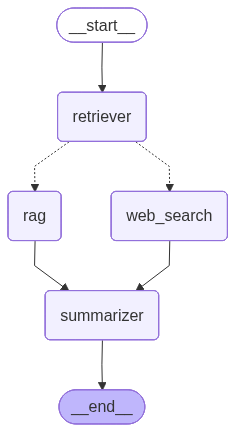

In [7]:
app